# Flight Delay Prediction — BTS Real Data (Jan 2025)
### Full EDA + Classification + Regression Pipeline

| | |
|---|---|
| **Dataset** | U.S. BTS On-Time Reporting (T_ONTIME_REPORTING.csv) |
| **Period** | January 2025 |
| **Records** | ~539,747 flights |
| **Task 1** | 🔵 Classification — Will flight be delayed > 15 min? |
| **Task 2** | 🟠 Regression — Predict arrival delay in minutes |
| **Models** | Logistic Regression, Random Forest, XGBoost |


---
## 📡 Section 1 — Data Ingestion

**Source:** [BTS On-Time Performance](https://transtats.bts.gov/)  
We'll use a publicly available sample CSV for local experimentation.

>  **How to download the real data:**
> 1. Go to https://transtats.bts.gov/
> 2. Navigate to: Airline On-Time Performance Data
> 3. Select columns and download as CSV
> 4. Place the CSV in the `data/raw/` folder



---
##  Section 0 — Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sklearn — classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

# Sklearn — regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

---
##  Section 1 — Data Loading

In [3]:
# ── UPDATE THIS PATH if needed ──
DATA_PATH = '../data/raw/T_ONTIME_REPORTING.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns : {df_raw.columns.tolist()}')
df_raw.head()

Loaded: 539,747 rows × 13 columns
Columns : ['YEAR', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 'ARR_DELAY', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY']


,YEAR,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_DELAY,TAXI_OUT,TAXI_IN,ARR_DELAY,DISTANCE,CARRIER_DELAY,WEATHER_DELAY
0,2025,1,1/1/2025 12:00:00 AM,AA,ABQ,DFW,-8.00,16.00,10.00,-21.00,569.00,NaN,NaN
1,2025,1,1/1/2025 12:00:00 AM,AA,ABQ,DFW,-5.00,13.00,11.00,-22.00,569.00,NaN,NaN
2,2025,1,1/1/2025 12:00:00 AM,AA,ABQ,DFW,-3.00,12.00,5.00,-23.00,569.00,NaN,NaN
3,2025,1,1/1/2025 12:00:00 AM,AA,ABQ,DFW,-3.00,13.00,13.00,-17.00,569.00,NaN,NaN
4,2025,1,1/1/2025 12:00:00 AM,AA,ABQ,DFW,7.00,20.00,19.00,17.00,569.00,7.00,0.00


In [4]:
print('Data Types:')
print(df_raw.dtypes)
print('\nBasic Statistics:')
df_raw.describe()

Data Types:
YEAR                   int64
MONTH                  int64
FL_DATE               object
OP_UNIQUE_CARRIER     object
ORIGIN                object
DEST                  object
DEP_DELAY            float64
TAXI_OUT             float64
TAXI_IN              float64
ARR_DELAY            float64
DISTANCE             float64
CARRIER_DELAY        float64
WEATHER_DELAY        float64
dtype: object

Basic Statistics:


,YEAR,MONTH,DEP_DELAY,TAXI_OUT,TAXI_IN,ARR_DELAY,DISTANCE,CARRIER_DELAY,WEATHER_DELAY
count,539747.00,539747.00,523824.00,523520.00,523167.00,522269.00,539747.00,98130.00,98130.00
mean,2025.00,1.00,10.34,19.06,8.32,3.76,843.21,25.59,6.42
std,0.00,0.00,54.33,11.23,6.80,56.85,599.09,76.79,47.50
min,2025.00,1.00,-50.00,1.00,1.00,-87.00,31.00,0.00,0.00
25%,2025.00,1.00,-6.00,12.00,5.00,-18.00,403.00,0.00,0.00
50%,2025.00,1.00,-3.00,16.00,6.00,-8.00,701.00,3.00,0.00
75%,2025.00,1.00,6.00,22.00,10.00,7.00,1083.00,23.00,0.00
max,2025.00,1.00,3298.00,182.00,212.00,3282.00,5095.00,3282.00,1765.00


---
## Section 2 — Exploratory Data Analysis (EDA)

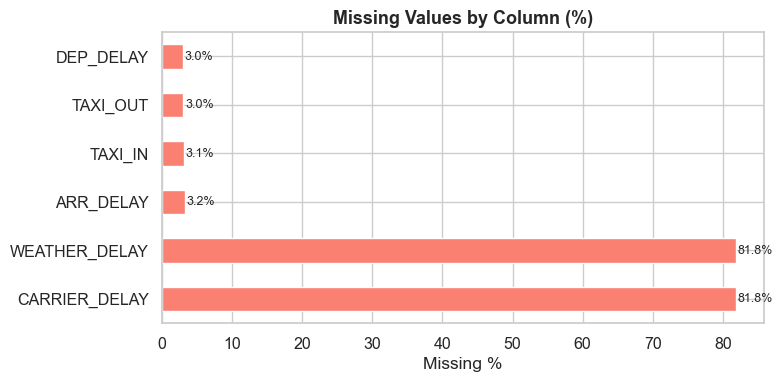

                Count  Pct (%)
CARRIER_DELAY  441617    81.82
WEATHER_DELAY  441617    81.82
ARR_DELAY       17478     3.24
TAXI_IN         16580     3.07
TAXI_OUT        16227     3.01
DEP_DELAY       15923     2.95


In [5]:
# ── 2.1 Missing Values ──
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df     = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
miss_df     = miss_df[miss_df['Count'] > 0].sort_values('Pct (%)', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
miss_df['Pct (%)'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing %')
for i, v in enumerate(miss_df['Pct (%)']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(miss_df)

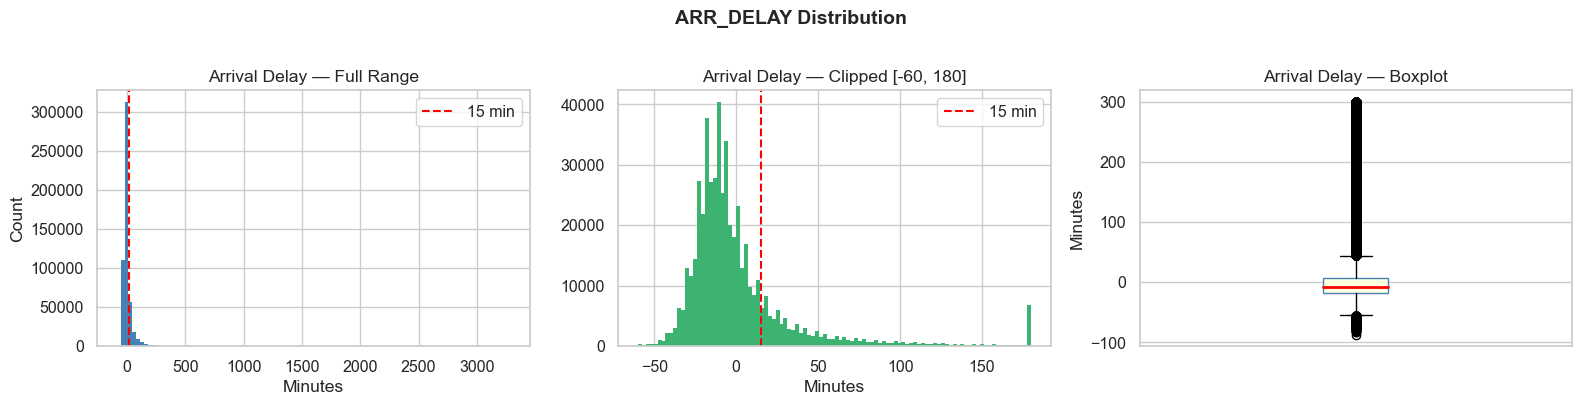

  Mean ARR_DELAY : 3.76 min
  Median         : -8.00 min
  Std Dev        : 56.85 min
  % Delayed >15m : 18.16%


In [6]:
# ── 2.2 Arrival Delay Distribution ──
arr = df_raw['ARR_DELAY'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution
axes[0].hist(arr, bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(15, color='red', linestyle='--', linewidth=1.5, label='15 min')
axes[0].set_title('Arrival Delay — Full Range')
axes[0].set_xlabel('Minutes'); axes[0].set_ylabel('Count')
axes[0].legend()

# Clipped view
axes[1].hist(arr.clip(-60, 180), bins=100, color='mediumseagreen', edgecolor='none')
axes[1].axvline(15, color='red', linestyle='--', linewidth=1.5, label='15 min')
axes[1].set_title('Arrival Delay — Clipped [-60, 180]')
axes[1].set_xlabel('Minutes')
axes[1].legend()

# Boxplot
axes[2].boxplot(arr.clip(-120, 300), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightyellow', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Arrival Delay — Boxplot')
axes[2].set_ylabel('Minutes')
axes[2].set_xticks([])

plt.suptitle('ARR_DELAY Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'  Mean ARR_DELAY : {arr.mean():.2f} min')
print(f'  Median         : {arr.median():.2f} min')
print(f'  Std Dev        : {arr.std():.2f} min')
print(f'  % Delayed >15m : {(arr > 15).mean():.2%}')

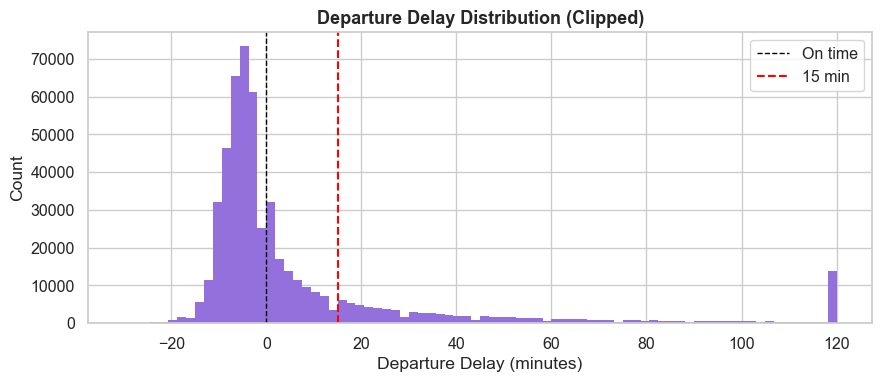

In [7]:
# ── 2.3 Departure Delay Distribution ──
dep = df_raw['DEP_DELAY'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dep.clip(-30, 120), bins=80, color='mediumpurple', edgecolor='none')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='On time')
ax.axvline(15, color='red', linestyle='--', linewidth=1.5, label='15 min')
ax.set_title('Departure Delay Distribution (Clipped)', fontsize=13, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

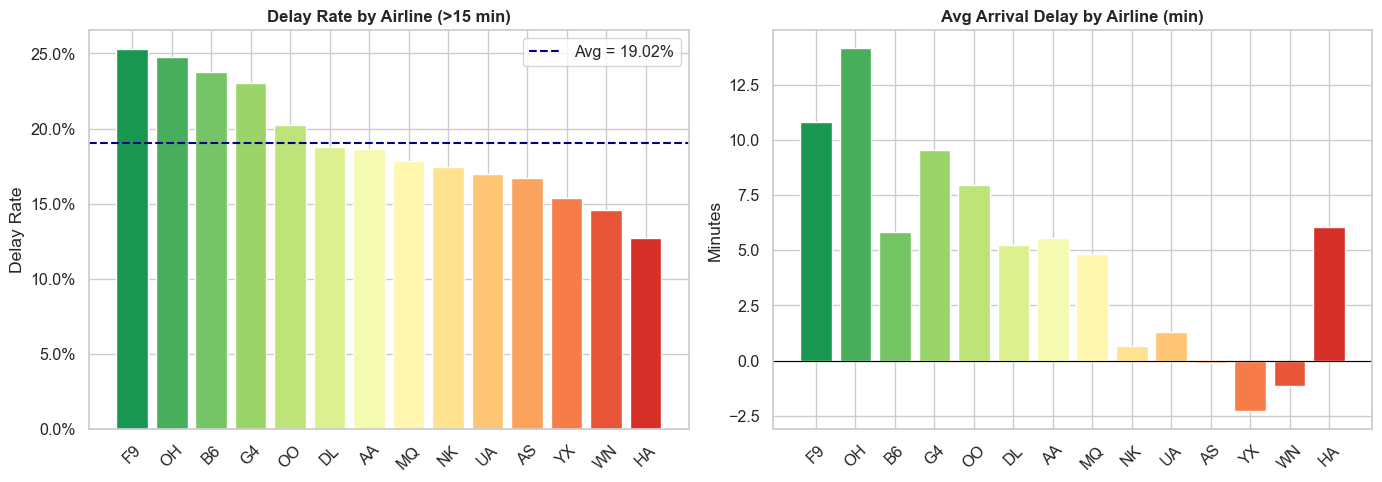

OP_UNIQUE_CARRIER  Total_Flights  Delay_Rate  Avg_Arr_Delay
               F9          15110        0.25          10.82
               OH          19151        0.25          14.14
               B6          17558        0.24           5.81
               G4           9206        0.23           9.54
               OO          63502        0.20           7.94
               DL          74025        0.19           5.22
               AA          72082        0.19           5.57
               MQ          20831        0.18           4.81
               NK          16946        0.17           0.65
               UA          60668        0.17           1.29
               AS          17847        0.17          -0.12
               YX          26683        0.15          -2.29
               WN         102120        0.15          -1.17
               HA           6540        0.13           6.04


In [8]:
# ── 2.4 Delay Rate by Airline ──
tmp = df_raw.dropna(subset=['ARR_DELAY'])
tmp['is_delayed'] = (tmp['ARR_DELAY'] > 15).astype(int)

airline_stats = tmp.groupby('OP_UNIQUE_CARRIER').agg(
    Total_Flights=('is_delayed', 'count'),
    Delay_Rate=('is_delayed', 'mean'),
    Avg_Arr_Delay=('ARR_DELAY', 'mean')
).sort_values('Delay_Rate', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(airline_stats)))

bars = axes[0].bar(airline_stats['OP_UNIQUE_CARRIER'], airline_stats['Delay_Rate'],
                   color=colors, edgecolor='white')
axes[0].axhline(airline_stats['Delay_Rate'].mean(), color='navy',
                linestyle='--', linewidth=1.5, label=f'Avg = {airline_stats["Delay_Rate"].mean():.2%}')
axes[0].set_title('Delay Rate by Airline (>15 min)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Delay Rate')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

bars2 = axes[1].bar(airline_stats['OP_UNIQUE_CARRIER'], airline_stats['Avg_Arr_Delay'],
                    color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_title('Avg Arrival Delay by Airline (min)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print(airline_stats.to_string(index=False))

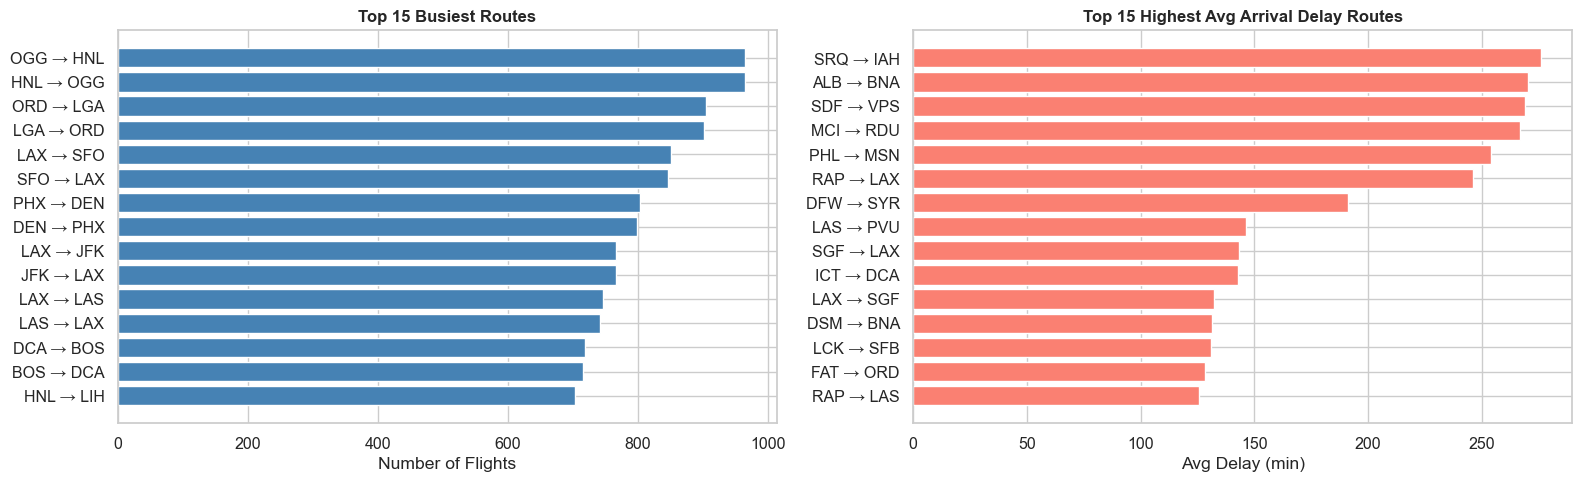

In [9]:
# ── 2.5 Top Busiest Routes & Worst Delay Routes ──
tmp['ROUTE'] = tmp['ORIGIN'] + ' → ' + tmp['DEST']

busiest = tmp['ROUTE'].value_counts().head(15).reset_index()
busiest.columns = ['Route', 'Flights']

worst_delay = tmp.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False).head(15).reset_index()
worst_delay.columns = ['Route', 'Avg Delay (min)']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(busiest['Route'][::-1], busiest['Flights'][::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Busiest Routes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Flights')

axes[1].barh(worst_delay['Route'][::-1], worst_delay['Avg Delay (min)'][::-1],
             color='salmon', edgecolor='white')
axes[1].set_title('Top 15 Highest Avg Arrival Delay Routes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Delay (min)')

plt.tight_layout()
plt.show()

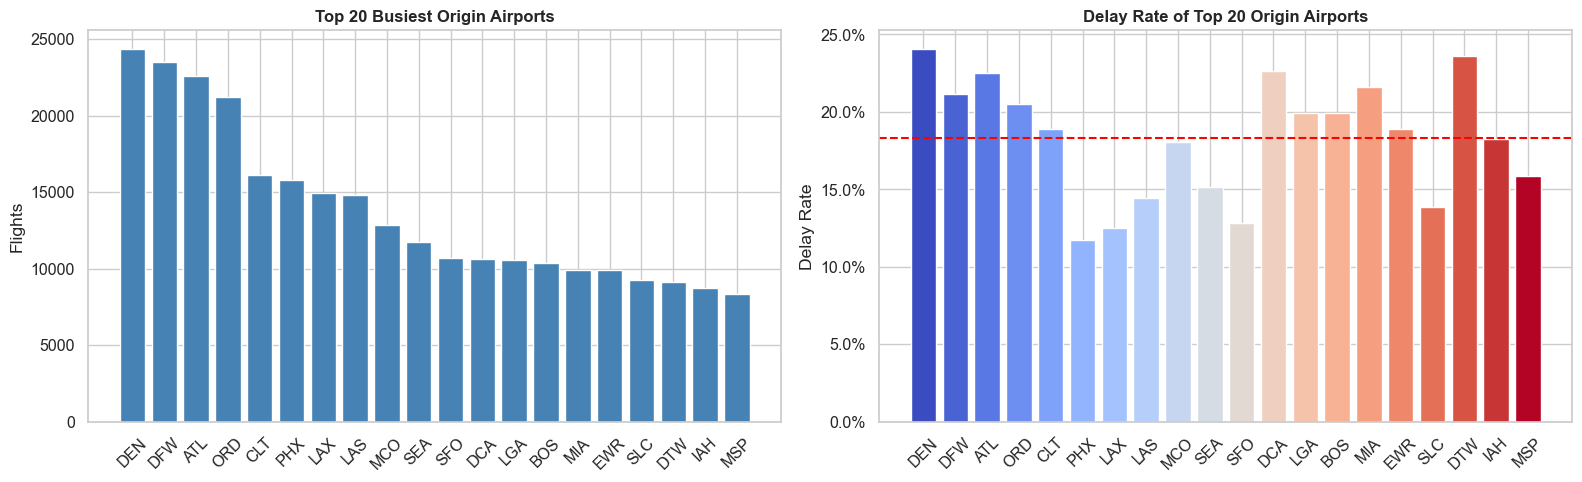

In [10]:
# ── 2.6 Top Origin & Destination Airports ──
top_origins = tmp.groupby('ORIGIN').agg(
    Flights=('ARR_DELAY', 'count'),
    Delay_Rate=('is_delayed', 'mean')
).sort_values('Flights', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

c = plt.cm.coolwarm(np.linspace(0, 1, 20))

axes[0].bar(top_origins.index, top_origins['Flights'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Busiest Origin Airports', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Flights')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_origins.index, top_origins['Delay_Rate'], color=c, edgecolor='white')
axes[1].axhline(top_origins['Delay_Rate'].mean(), color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Delay Rate of Top 20 Origin Airports', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Delay Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

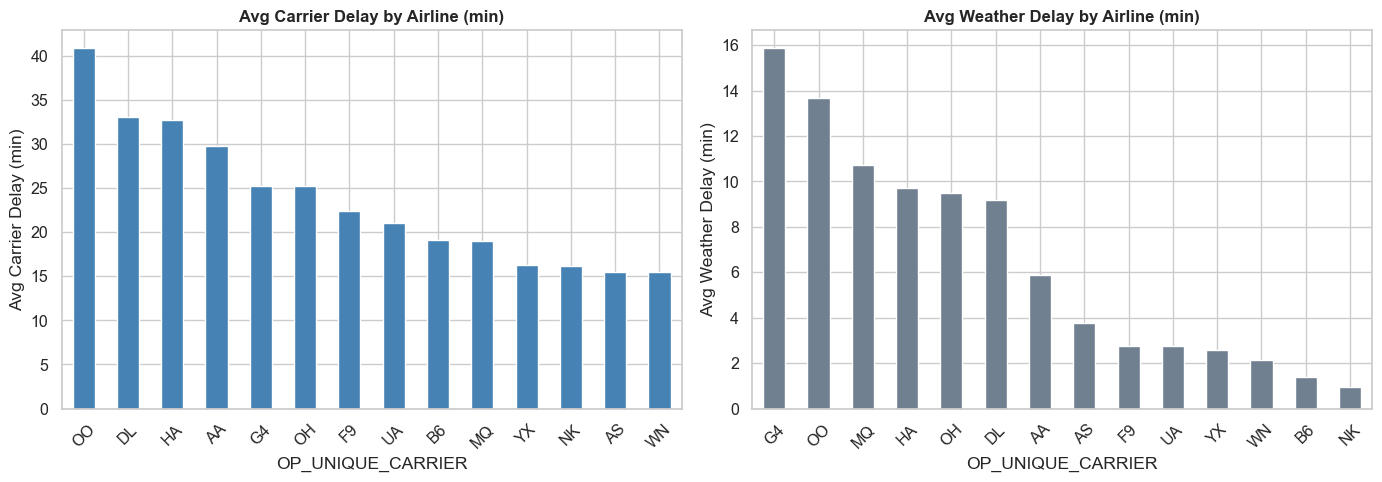

In [11]:
# ── 2.7 Delay Breakdown: Carrier vs Weather ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

carrier_by_airline = tmp.groupby('OP_UNIQUE_CARRIER')['CARRIER_DELAY'].mean()
weather_by_airline = tmp.groupby('OP_UNIQUE_CARRIER')['WEATHER_DELAY'].mean()

carrier_by_airline.sort_values(ascending=False).plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Avg Carrier Delay by Airline (min)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Carrier Delay (min)')
axes[0].tick_params(axis='x', rotation=45)

weather_by_airline.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
    color='slategray', edgecolor='white')
axes[1].set_title('Avg Weather Delay by Airline (min)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Weather Delay (min)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

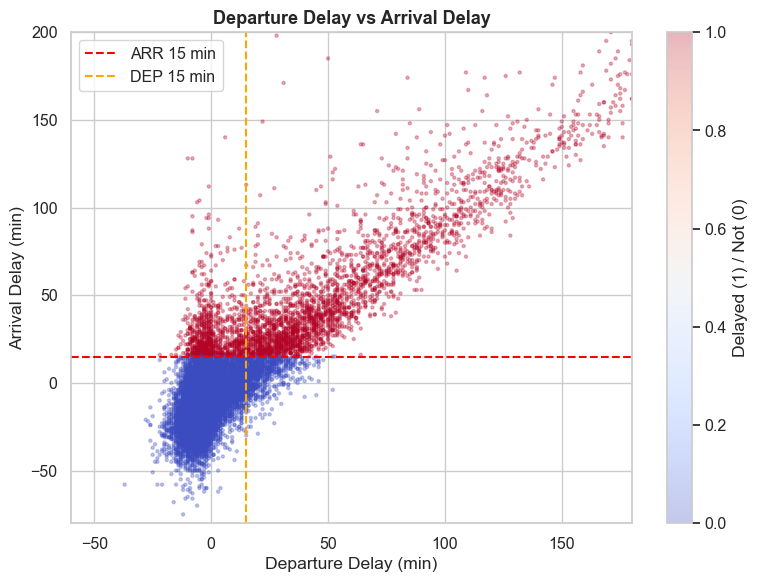

Pearson correlation DEP_DELAY ↔ ARR_DELAY: 0.9633


In [12]:
# ── 2.8 Departure vs Arrival Delay Scatter ──
sample = tmp.sample(n=min(20000, len(tmp)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(sample['DEP_DELAY'], sample['ARR_DELAY'],
                     c=sample['is_delayed'], cmap='coolwarm',
                     alpha=0.3, s=5)
ax.axhline(15, color='red', linestyle='--', linewidth=1.5, label='ARR 15 min')
ax.axvline(15, color='orange', linestyle='--', linewidth=1.5, label='DEP 15 min')
ax.set_xlim(-60, 180); ax.set_ylim(-80, 200)
ax.set_xlabel('Departure Delay (min)')
ax.set_ylabel('Arrival Delay (min)')
ax.set_title('Departure Delay vs Arrival Delay', fontsize=13, fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Delayed (1) / Not (0)')
plt.tight_layout()
plt.show()

corr = tmp[['DEP_DELAY','ARR_DELAY']].corr().iloc[0,1]
print(f'Pearson correlation DEP_DELAY ↔ ARR_DELAY: {corr:.4f}')

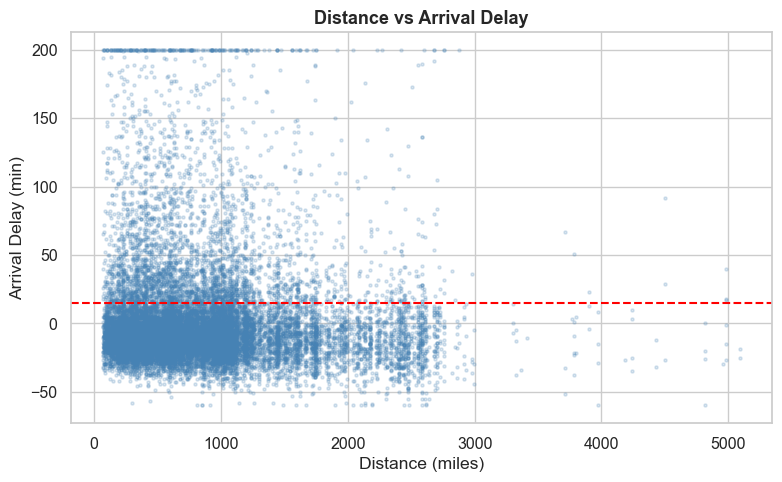

In [13]:
# ── 2.9 Distance vs Arrival Delay ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['DISTANCE'], sample['ARR_DELAY'].clip(-60, 200),
           alpha=0.2, s=5, c='steelblue')
ax.axhline(15, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Arrival Delay (min)')
ax.set_title('Distance vs Arrival Delay', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

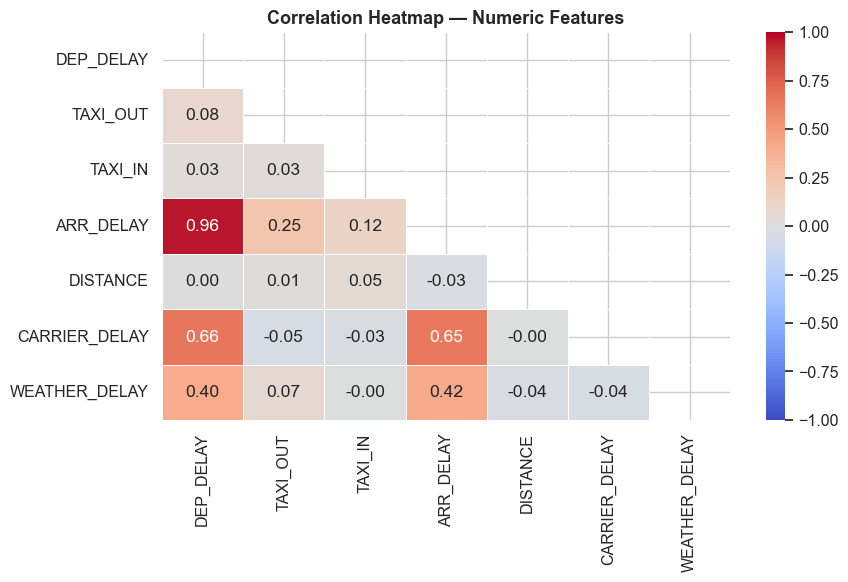

In [14]:
# ── 2.10 Correlation Heatmap ──
num_cols = ['DEP_DELAY','TAXI_OUT','TAXI_IN','ARR_DELAY',
            'DISTANCE','CARRIER_DELAY','WEATHER_DELAY']
corr_matrix = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, mask=mask, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

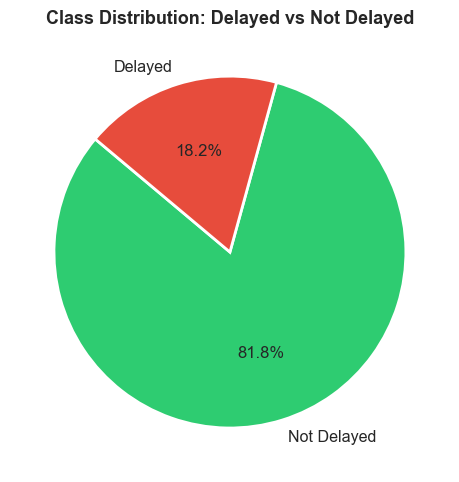

Not Delayed : 427,445 (81.84%)
Delayed     : 94,824 (18.16%)


In [15]:
# ── 2.11 Delay Pie Chart ──
delay_counts = tmp['is_delayed'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    delay_counts,
    labels=['Not Delayed', 'Delayed'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12)
ax.set_title('Class Distribution: Delayed vs Not Delayed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Not Delayed : {delay_counts[0]:,} ({delay_counts[0]/len(tmp):.2%})')
print(f'Delayed     : {delay_counts[1]:,} ({delay_counts[1]/len(tmp):.2%})')

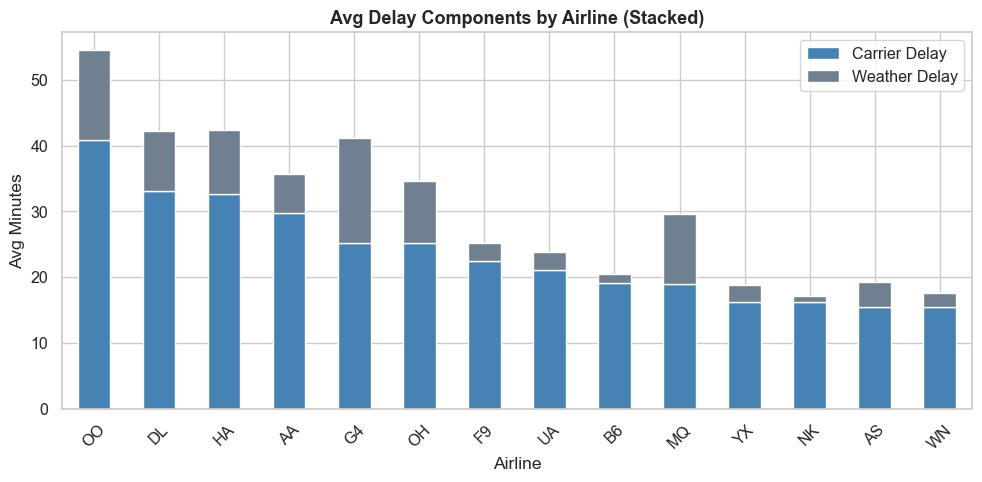

In [16]:
# ── 2.12 Delay Components Stacked — Carrier vs Weather ──
delay_components = tmp.groupby('OP_UNIQUE_CARRIER')[['CARRIER_DELAY','WEATHER_DELAY']].mean().fillna(0)
delay_components = delay_components.sort_values('CARRIER_DELAY', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
delay_components.plot(kind='bar', ax=ax,
    color=['steelblue','slategray'], edgecolor='white', stacked=True)
ax.set_title('Avg Delay Components by Airline (Stacked)', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Minutes')
ax.set_xlabel('Airline')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Carrier Delay', 'Weather Delay'])
plt.tight_layout()
plt.show()

---
##  Section 3 — Data Cleaning & Feature Engineering

In [17]:
df = df_raw.copy()
print(f'Initial shape: {df.shape}')

# 1. Drop rows without target
df = df.dropna(subset=['ARR_DELAY', 'DEP_DELAY'])
print(f'After dropping null ARR/DEP_DELAY: {df.shape}')

# 2. Remove extreme outliers
df = df[(df['ARR_DELAY'] > -120) & (df['ARR_DELAY'] < 600)]
df = df[(df['DEP_DELAY'] > -120) & (df['DEP_DELAY'] < 600)]
print(f'After outlier removal: {df.shape}')

# 3. Fill delay columns with 0 (NaN means no delay of that type)
df['CARRIER_DELAY'] = df['CARRIER_DELAY'].fillna(0)
df['WEATHER_DELAY'] = df['WEATHER_DELAY'].fillna(0)

# 4. Fill TAXI columns with median
df['TAXI_OUT'] = df['TAXI_OUT'].fillna(df['TAXI_OUT'].median())
df['TAXI_IN']  = df['TAXI_IN'].fillna(df['TAXI_IN'].median())

print(f'\n Cleaned shape: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Initial shape: (539747, 13)
After dropping null ARR/DEP_DELAY: (522269, 13)
After outlier removal: (521518, 13)

 Cleaned shape: (521518, 13)
Remaining nulls: 0


In [18]:
# ── Feature Engineering ──

# Parse FL_DATE
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek + 1   # 1=Mon … 7=Sun
df['DAY_OF_MONTH'] = df['FL_DATE'].dt.day

# Weekend flag
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# Distance buckets
df['DIST_BUCKET'] = pd.cut(
    df['DISTANCE'],
    bins=[0, 500, 1000, 1500, 2000, 10000],
    labels=['VeryShort', 'Short', 'Medium', 'Long', 'VeryLong']
)

# Route
df['ROUTE'] = df['ORIGIN'] + '_' + df['DEST']

# Encode categoricals
le = {}
for col in ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DIST_BUCKET', 'ROUTE']:
    le[col] = LabelEncoder()
    df[col + '_ENC'] = le[col].fit_transform(df[col].astype(str))

# Classification target
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

print(' Features engineered!')
print(df.shape)
df[['DEP_DELAY','TAXI_OUT','TAXI_IN','DISTANCE','DAY_OF_WEEK','IS_WEEKEND',
    'CARRIER_DELAY','WEATHER_DELAY','IS_DELAYED','ARR_DELAY']].describe()

 Features engineered!
(521518, 24)


,DEP_DELAY,TAXI_OUT,TAXI_IN,DISTANCE,DAY_OF_WEEK,IS_WEEKEND,CARRIER_DELAY,WEATHER_DELAY,IS_DELAYED,ARR_DELAY
count,521518.00,521518.00,521518.00,521518.00,521518.00,521518.00,521518.00,521518.00,521518.00,521518.00
mean,8.92,19.04,8.31,847.11,4.02,0.25,4.13,0.92,0.18,2.43
std,39.57,11.20,6.78,601.75,1.93,0.44,22.74,12.60,0.38,43.21
min,-50.00,1.00,1.00,31.00,1.00,0.00,0.00,0.00,0.00,-87.00
25%,-6.00,12.00,5.00,403.00,2.00,0.00,0.00,0.00,0.00,-18.00
50%,-3.00,16.00,6.00,712.00,4.00,0.00,0.00,0.00,0.00,-8.00
75%,6.00,22.00,10.00,1085.00,6.00,1.00,0.00,0.00,0.00,7.00
max,599.00,182.00,212.00,5095.00,7.00,1.00,588.00,585.00,1.00,599.00


In [19]:
# Save cleaned and Feature Engineered DataFrame
df.to_csv('../data/cleaned/T_ONTIME_REPORTING_cleaned.csv')

---
##  Section 4 — TASK 1: Classification (Delayed > 15 min?)

CLF_FEATURES --> classification_features
CLF_TARGET --> classification_target

In [21]:
CLF_FEATURES = [
    'OP_UNIQUE_CARRIER_ENC',
    'ORIGIN_ENC',
    'DEST_ENC',
    'ROUTE_ENC',
    'DISTANCE',
    'DIST_BUCKET_ENC',
    'TAXI_OUT',
    'TAXI_IN',
    'DAY_OF_WEEK',
    'DAY_OF_MONTH',
    'IS_WEEKEND',
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'DEP_DELAY', 
]
CLF_TARGET = 'IS_DELAYED'

X_clf = df[CLF_FEATURES]
y_clf = df[CLF_TARGET]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale for Logistic Regression
scaler_clf = StandardScaler()
X_clf_train_sc = scaler_clf.fit_transform(X_clf_train)
X_clf_test_sc  = scaler_clf.transform(X_clf_test)

print(f'Train: {X_clf_train.shape[0]:,} | Test: {X_clf_test.shape[0]:,}')


Train: 417,214 | Test: 104,304


In [22]:
# ── Helper: Evaluate Classifier ──
def eval_clf(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_prob),
    }
    print(f'\n{"-"*50}\n  {name}\n{"-"*50}')
    for k, v in metrics.items():
        if k != 'Model': print(f'  {k:<12}: {v:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["Not Delayed","Delayed"])}')
    return model, metrics, y_pred, y_prob

In [23]:
# ── CLF Model 1: Logistic Regression ──
lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf_m, lr_clf_mt, lr_clf_pred, lr_clf_prob = eval_clf(
    'Logistic Regression', lr_clf,
    X_clf_train_sc, y_clf_train,
    X_clf_test_sc,  y_clf_test
)


--------------------------------------------------
  Logistic Regression
--------------------------------------------------
  Accuracy    : 0.9507
  Precision   : 0.8221
  Recall      : 0.9276
  F1          : 0.8717
  ROC-AUC     : 0.9841

              precision    recall  f1-score   support

 Not Delayed       0.98      0.96      0.97     85489
     Delayed       0.82      0.93      0.87     18815

    accuracy                           0.95    104304
   macro avg       0.90      0.94      0.92    104304
weighted avg       0.95      0.95      0.95    104304



In [24]:
# ── CLF Model 2: Random Forest ──
rf_clf = RandomForestClassifier(
    n_estimators=150, max_depth=12,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clf_m, rf_clf_mt, rf_clf_pred, rf_clf_prob = eval_clf(
    'Random Forest', rf_clf,
    X_clf_train, y_clf_train,
    X_clf_test,  y_clf_test
)


--------------------------------------------------
  Random Forest
--------------------------------------------------
  Accuracy    : 0.9607
  Precision   : 0.8644
  Recall      : 0.9275
  F1          : 0.8948
  ROC-AUC     : 0.9876

              precision    recall  f1-score   support

 Not Delayed       0.98      0.97      0.98     85489
     Delayed       0.86      0.93      0.89     18815

    accuracy                           0.96    104304
   macro avg       0.92      0.95      0.94    104304
weighted avg       0.96      0.96      0.96    104304



In [25]:
# ── CLF Model 3: XGBoost ──
scale_pos = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()
xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_clf_m, xgb_clf_mt, xgb_clf_pred, xgb_clf_prob = eval_clf(
    'XGBoost', xgb_clf,
    X_clf_train, y_clf_train,
    X_clf_test,  y_clf_test
)


--------------------------------------------------
  XGBoost
--------------------------------------------------
  Accuracy    : 0.9641
  Precision   : 0.8699
  Recall      : 0.9417
  F1          : 0.9044
  ROC-AUC     : 0.9913

              precision    recall  f1-score   support

 Not Delayed       0.99      0.97      0.98     85489
     Delayed       0.87      0.94      0.90     18815

    accuracy                           0.96    104304
   macro avg       0.93      0.96      0.94    104304
weighted avg       0.97      0.96      0.96    104304




 Classification Results:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.95,0.82,0.93,0.87,0.98
Random Forest,0.96,0.86,0.93,0.89,0.99
XGBoost,0.96,0.87,0.94,0.90,0.99


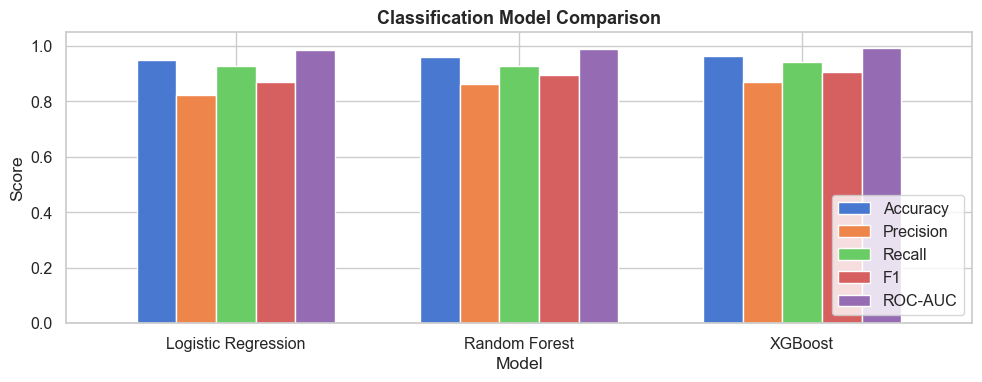

In [26]:
# ── Classification Comparison ──
clf_results = pd.DataFrame([lr_clf_mt, rf_clf_mt, xgb_clf_mt]).set_index('Model').round(4)
print('\n Classification Results:')
display(clf_results)

fig, ax = plt.subplots(figsize=(10, 4))
clf_results.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Classification Model Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

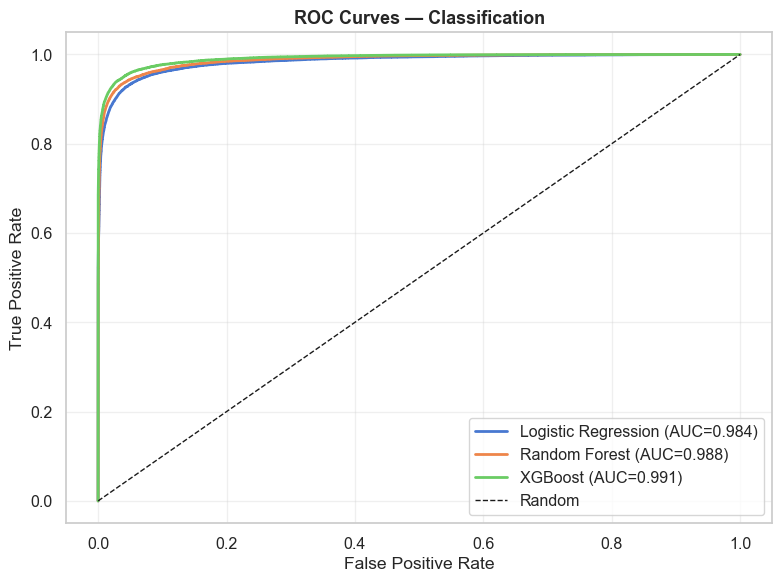

In [27]:
# ── ROC Curves ──
fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in [('Logistic Regression', lr_clf_prob),
                   ('Random Forest', rf_clf_prob),
                   ('XGBoost', xgb_clf_prob)]:
    fpr, tpr, _ = roc_curve(y_clf_test, prob)
    auc = roc_auc_score(y_clf_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Classification', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

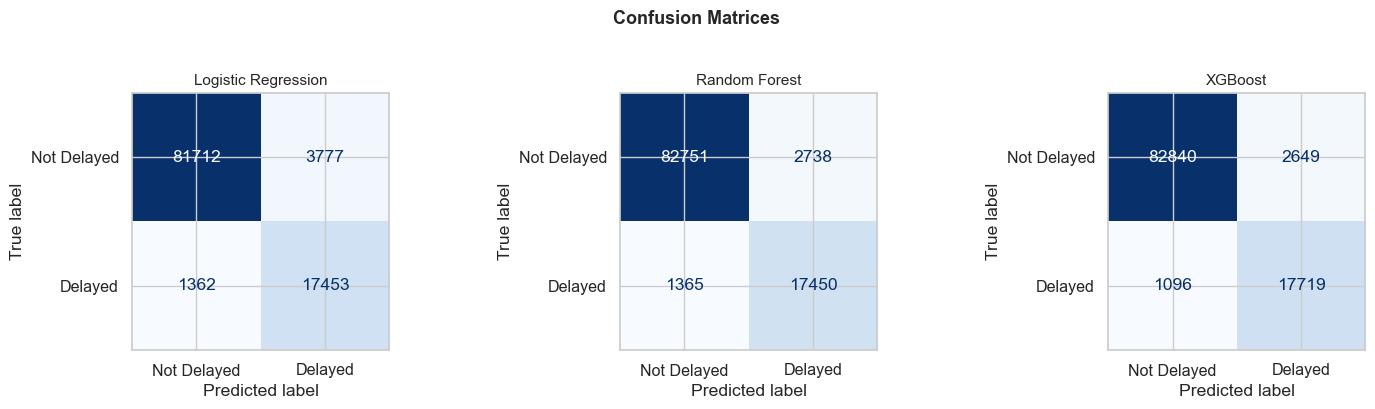

In [28]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_clf_pred),
    ('Random Forest',       rf_clf_pred),
    ('XGBoost',             xgb_clf_pred)
]):
    cm = confusion_matrix(y_clf_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Delayed','Delayed']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

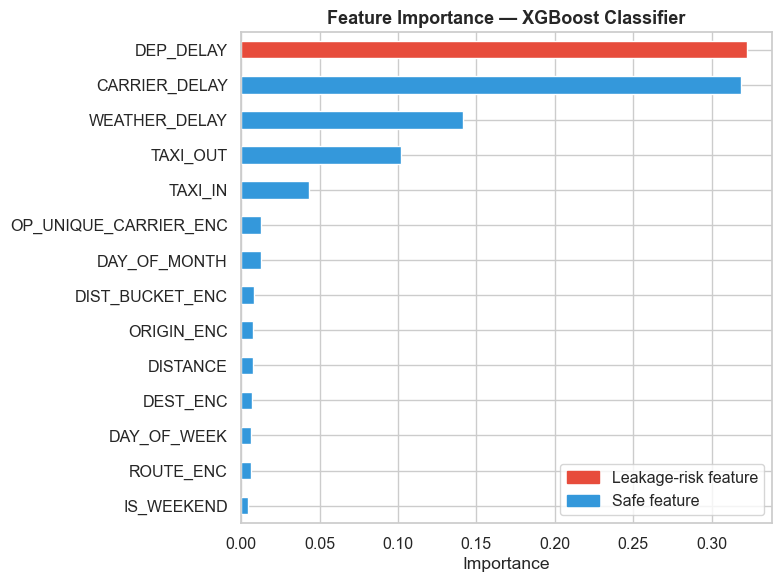

In [29]:
# ── Feature Importance — XGBoost Classifier ──
fi = pd.Series(xgb_clf_m.feature_importances_, index=CLF_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if f == 'DEP_DELAY' else '#3498db' for f in fi.index]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — XGBoost Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='Leakage-risk feature'),
    Patch(color='#3498db', label='Safe feature')
])
plt.tight_layout(); plt.show()

---
##  Section 5 — TASK 2: Regression (Predict ARR_DELAY in minutes)

In [30]:
REG_FEATURES = [
    'OP_UNIQUE_CARRIER_ENC',
    'ORIGIN_ENC',
    'DEST_ENC',
    'ROUTE_ENC',
    'DISTANCE',
    'DIST_BUCKET_ENC',
    'TAXI_OUT',
    'TAXI_IN',
    'DAY_OF_WEEK',
    'DAY_OF_MONTH',
    'IS_WEEKEND',
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'DEP_DELAY',
]
REG_TARGET = 'ARR_DELAY'

X_reg = df[REG_FEATURES]
y_reg = df[REG_TARGET]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print(f'Train: {X_reg_train.shape[0]:,} | Test: {X_reg_test.shape[0]:,}')

Train: 417,214 | Test: 104,304


In [31]:
# ── Helper: Evaluate Regressor ──
def eval_reg(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    metrics = {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f'\n{"-"*50}\n  {name}\n{"-"*50}')
    print(f'  MAE  : {mae:.2f} min')
    print(f'  RMSE : {rmse:.2f} min')
    print(f'  R²   : {r2:.4f}')
    return model, metrics, y_pred

In [32]:
# ── REG Model 1: Ridge Regression ──
ridge = Ridge(alpha=1.0)
ridge_m, ridge_mt, ridge_pred = eval_reg(
    'Ridge Regression', ridge,
    X_reg_train_sc, y_reg_train,
    X_reg_test_sc,  y_reg_test
)


--------------------------------------------------
  Ridge Regression
--------------------------------------------------
  MAE  : 7.88 min
  RMSE : 10.45 min
  R²   : 0.9417


In [33]:
# ── REG Model 2: Random Forest Regressor ──
rf_reg = RandomForestRegressor(
    n_estimators=150, max_depth=12, random_state=42, n_jobs=-1
)
rf_reg_m, rf_reg_mt, rf_reg_pred = eval_reg(
    'Random Forest', rf_reg,
    X_reg_train, y_reg_train,
    X_reg_test,  y_reg_test
)


--------------------------------------------------
  Random Forest
--------------------------------------------------
  MAE  : 7.48 min
  RMSE : 10.03 min
  R²   : 0.9463


In [34]:
# ── REG Model 3: XGBoost Regressor ──
xgb_reg = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_reg_m, xgb_reg_mt, xgb_reg_pred = eval_reg(
    'XGBoost', xgb_reg,
    X_reg_train, y_reg_train,
    X_reg_test,  y_reg_test
)


--------------------------------------------------
  XGBoost
--------------------------------------------------
  MAE  : 6.63 min
  RMSE : 9.49 min
  R²   : 0.9519



 Regression Results:


,MAE,RMSE,R²
Model,,,
Ridge Regression,7.88,10.45,0.94
Random Forest,7.48,10.03,0.95
XGBoost,6.63,9.49,0.95


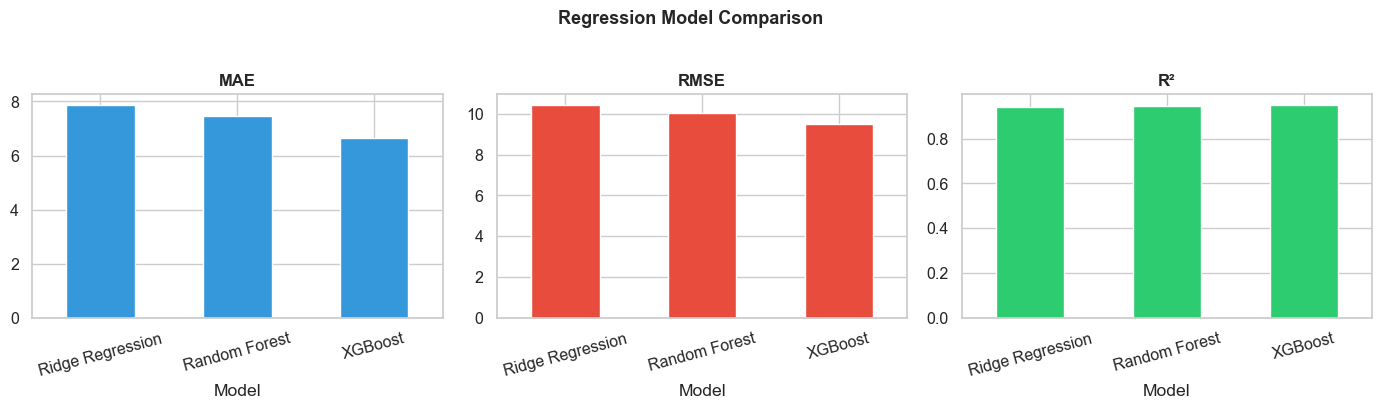

In [35]:
# ── Regression Comparison Table ──
reg_results = pd.DataFrame([ridge_mt, rf_reg_mt, xgb_reg_mt]).set_index('Model').round(4)
print('\n Regression Results:')
display(reg_results)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_reg = ['MAE', 'RMSE', 'R²']
colors_reg  = ['#3498db', '#e74c3c', '#2ecc71']
for ax, m, c in zip(axes, metrics_reg, colors_reg):
    reg_results[m].plot(kind='bar', ax=ax, color=c, edgecolor='white')
    ax.set_title(m, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Regression Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

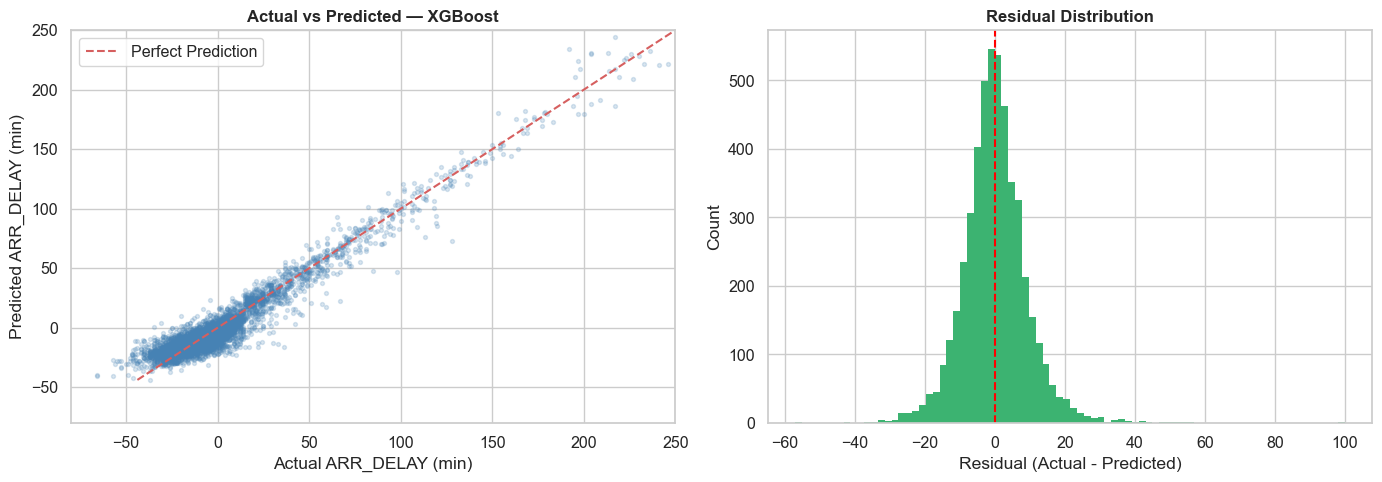

Residual Mean : 0.07
Residual Std  : 9.52


In [36]:
# ── Actual vs Predicted — XGBoost Regressor ──
sample_idx = np.random.choice(len(y_reg_test), 5000, replace=False)
y_sample   = np.array(y_reg_test)[sample_idx]
yp_sample  = xgb_reg_pred[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_sample, yp_sample, alpha=0.2, s=8, color='steelblue')
lims = [max(y_sample.min(), yp_sample.min()),
        min(y_sample.max(), yp_sample.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual ARR_DELAY (min)')
axes[0].set_ylabel('Predicted ARR_DELAY (min)')
axes[0].set_title('Actual vs Predicted — XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlim(-80, 250); axes[0].set_ylim(-80, 250)
axes[0].legend()

# Residuals
residuals = y_sample - yp_sample
axes[1].hist(residuals.clip(-100, 100), bins=80, color='mediumseagreen', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

print(f'Residual Mean : {residuals.mean():.2f}')
print(f'Residual Std  : {residuals.std():.2f}')

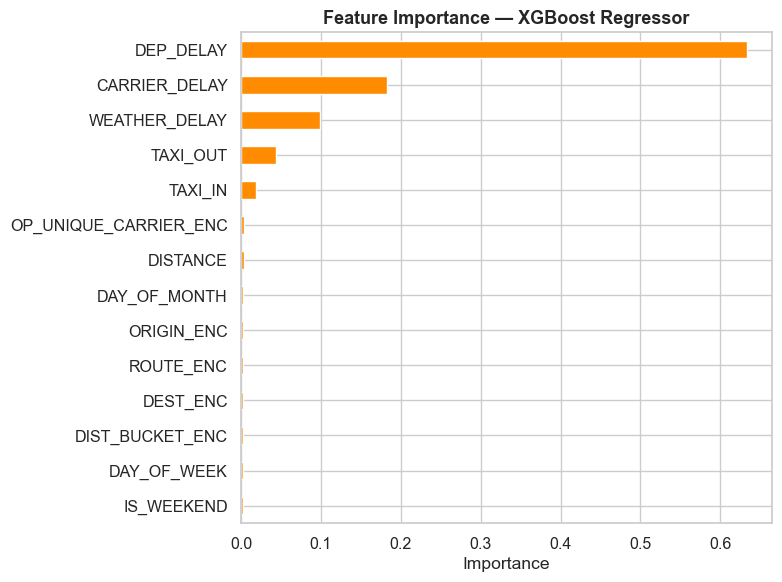

In [37]:
# ── Feature Importance — XGBoost Regressor ──
fi_reg = pd.Series(xgb_reg_m.feature_importances_, index=REG_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
fi_reg.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Feature Importance — XGBoost Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

---
##  Section 6 — Save Models

In [51]:
# ── Select Best Classification Model by ROC-AUC ──
clf_candidates = {
    'Logistic Regression': {
        'model'   : lr_clf_m,
        'metrics' : lr_clf_mt,
        'scaled'  : True,    # needs scaler_clf at inference
    },
    'Random Forest': {
        'model'   : rf_clf_m,
        'metrics' : rf_clf_mt,
        'scaled'  : False,
    },
    'XGBoost': {
        'model'   : xgb_clf_m,
        'metrics' : xgb_clf_mt,
        'scaled'  : False,
    },
}

# Selection criterion: ROC-AUC (primary) → F1 (tiebreaker)
best_clf_name = max(
    clf_candidates,
    key=lambda k: (clf_candidates[k]['metrics']['ROC-AUC'],
                   clf_candidates[k]['metrics']['F1'])
)
best_clf = clf_candidates[best_clf_name]

In [52]:
best_clf

{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=-1,
               num_parallel_tree=None, ...),
 'metrics': {'Model': 'XGBoost',
  'Accuracy': 0.9640953367080841,
  'Precision': 0.8699430479183032,
  'Recall': 0.9417486048365665,
  'F1': 0.9044228364341679,
  'ROC-AUC': 0.9912997364924174},
 'scaled':

In [54]:
# --- Best Classifier ---
joblib.dump(best_clf['model'], f"../models/{best_clf['metrics']['Model']}_clf.pkl")
if best_clf['scaled']:
    joblib.dump(scaler_clf, f"../models/best_clf_scaler.pkl")

In [55]:
# ── Select Best Regression Model by R² 
reg_candidates = {
    'Ridge Regression': {
        'model'   : ridge_m,
        'metrics' : ridge_mt,
        'scaled'  : True,
    },
    'Random Forest': {
        'model'   : rf_reg_m,
        'metrics' : rf_reg_mt,
        'scaled'  : False,
    },
    'XGBoost': {
        'model'   : xgb_reg_m,
        'metrics' : xgb_reg_mt,
        'scaled'  : False,
    },
}

# Selection criterion: highest R² → lowest MAE (tiebreaker)
best_reg_name = max(
    reg_candidates,
    key=lambda k: (reg_candidates[k]['metrics']['R²'],
                  -reg_candidates[k]['metrics']['MAE'])
)
best_reg = reg_candidates[best_reg_name]

In [56]:
best_reg

{'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...),
 'metrics': {'Model': 'XGBoost',
  'MAE': 6.631985755514118,
  'RMSE': 9.488893674950251,
  'R²': 0.951908037524003},
 'scaled': False}

In [57]:
# --- Best Regressor ---
joblib.dump(best_reg['model'], f"../models/{best_reg['metrics']['Model']}_reg.pkl")
if best_reg['scaled']:
    joblib.dump(scaler_reg, f"../models/best_reg_scaler.pkl")

In [59]:
joblib.dump(le, f"../models/label_encoders.pkl")

['../models/label_encoders.pkl']

In [63]:
m = joblib.load(f"../models/XGBoost_clf.pkl")

In [ ]:
m.

array([0, 1])

---
## Section 7 — Inference Example

In [61]:
# Load best models
clf_model = joblib.load(f"../models/XGBOOST_clf.pkl")
reg_model = joblib.load(f"../models/XGBOOST_reg.pkl")
encoders  = joblib.load(f'../models/label_encoders.pkl')

# Example flight input
def predict_flight(airline, origin, dest, distance, dep_delay,
                   taxi_out, taxi_in, day_of_week, day_of_month,
                   carrier_delay=0, weather_delay=0):

    is_weekend   = 1 if day_of_week >= 6 else 0
    route        = f'{origin}_{dest}'
    dist_bucket  = pd.cut([distance],
                          bins=[0,500,1000,1500,2000,10000],
                          labels=['VeryShort','Short','Medium','Long','VeryLong'])[0]

    def safe_encode(enc, val):
        classes = list(enc.classes_)
        return enc.transform([val])[0] if val in classes else -1

    sample = {
        'OP_UNIQUE_CARRIER_ENC' : safe_encode(encoders['OP_UNIQUE_CARRIER'], airline),
        'ORIGIN_ENC'            : safe_encode(encoders['ORIGIN'], origin),
        'DEST_ENC'              : safe_encode(encoders['DEST'], dest),
        'ROUTE_ENC'             : safe_encode(encoders['ROUTE'], route),
        'DISTANCE'              : distance,
        'DIST_BUCKET_ENC'       : safe_encode(encoders['DIST_BUCKET'], str(dist_bucket)),
        'TAXI_OUT'              : taxi_out,
        'TAXI_IN'               : taxi_in,
        'DAY_OF_WEEK'           : day_of_week,
        'DAY_OF_MONTH'          : day_of_month,
        'IS_WEEKEND'            : is_weekend,
        'CARRIER_DELAY'         : carrier_delay,
        'WEATHER_DELAY'         : weather_delay,
        'DEP_DELAY'             : dep_delay,
    }
    X_inp = pd.DataFrame([sample])

    clf_prob  = clf_model.predict_proba(X_inp)[0][1]
    clf_pred  = clf_model.predict(X_inp)[0]
    reg_pred  = reg_model.predict(X_inp)[0]

    print('='*50)
    print(f'  Flight: {airline}  {origin} → {dest}')
    print(f'  Distance   : {distance} miles')
    print(f'  Dep Delay  : {dep_delay} min')
    print(f'  Day        : {day_of_week} (Weekend={is_weekend})')
    print('='*50)
    print(f'  CLASSIFICATION')
    print(f'     Delay Probability : {clf_prob:.2%}')
    print(f'     Prediction        : {"DELAYED" if clf_pred==1 else "ON TIME"}')
    print(f'\n REGRESSION')
    print(f'     Predicted Arrival Delay : {reg_pred:.1f} min')
    print('='*50)

# ── Run inference ──
predict_flight(
    airline='AA', origin='ATL', dest='LAX',
    distance=1946, dep_delay=20,
    taxi_out=18, taxi_in=9,
    day_of_week=5, day_of_month=15
)

  Flight: AA  ATL → LAX
  Distance   : 1946 miles
  Dep Delay  : 20 min
  Day        : 5 (Weekend=0)
  CLASSIFICATION
     Delay Probability : 11.88%
     Prediction        : ON TIME

 REGRESSION
     Predicted Arrival Delay : 2.0 min


In [62]:
# Try another flight
predict_flight(
    airline='DL', origin='JFK', dest='ORD',
    distance=740, dep_delay=5,
    taxi_out=25, taxi_in=8,
    day_of_week=7, day_of_month=3,  # Sunday
    weather_delay=15
)

  Flight: DL  JFK → ORD
  Distance   : 740 miles
  Dep Delay  : 5 min
  Day        : 7 (Weekend=1)
  CLASSIFICATION
     Delay Probability : 34.36%
     Prediction        : ON TIME

 REGRESSION
     Predicted Arrival Delay : 16.2 min


---
## Summary

| | Task | Best Model | Key Metric |
|---|---|---|---|
| 🔵 | Classification (Delayed >15 min) | XGBoost | ROC-AUC |
| 🟠 | Regression (ARR_DELAY minutes) | XGBoost | MAE / R² |
